# SNR Percentile Distribution & Molecular Detection Thresholds

## Setup

In [1]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit
import tensorflow as tf
from tqdm import tqdm

from geexhp import datavis

datavis.configure_matplotlib()
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

2026-05-03 12:39:57.711791: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-03 12:39:57.713106: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-03 12:39:57.721253: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-03 12:39:57.741427: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777822797.771730 3420281 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777822797.77

In [ ]:
SNR_SCALES = [0.5, 1.0, 2.0, 4.0]

TELESCOPE_CONFIG = {
    "LUVOIR": {
        "prefix": "B",
        "bins": {"UV": 8, "Vis": 94, "NIR": 49},
        "aperture_m": 8.0,
    },
    "HABEX": {
        "prefix": "SS",
        "bins": {"UV": 7, "Vis": 109, "NIR": 25},
        "aperture_m": 4.0,
    },
}

PHYS_PARAMS = [
    "OBJECT-RADIUS-REL-EARTH",
    "OBJECT-GRAVITY",
    "ATMOSPHERE-TEMPERATURE",
    "ATMOSPHERE-PRESSURE",
]
MAIN_CHEM = ["O2", "O3"]
OTHER_CHEM = ["CH4", "CO2", "H2O", "N2"]
ALL_PARAMS = PHYS_PARAMS + MAIN_CHEM + OTHER_CHEM

PARAM_LABELS = [
    r"R$_\oplus$",
    r"$g$",
    r"$T_{\rm surf}$",
    r"$P_{\rm surf}$",
    r"O$_2$",
    r"O$_3$",
    r"CH$_4$",
    r"CO$_2$",
    r"H$_2$O",
    r"N$_2$",
]
N_PARAMS = len(PARAM_LABELS)

CHEM_IDX = {"O2": 4, "O3": 5, "CH4": 6, "CO2": 7, "H2O": 8, "N2": 9}
CHEM_LABEL = {
    "O2": r"O$_2$",
    "O3": r"O$_3$",
    "CH4": r"CH$_4$",
    "CO2": r"CO$_2$",
    "H2O": r"H$_2$O",
    "N2": r"N$_2$",
}

ERA_ORDER = ["modern", "proterozoic", "archean"]
ERA_COLORS = {"modern": "tab:blue", "proterozoic": "tab:green", "archean": "tab:orange"}

TEL_COLORS = {"LUVOIR": "#223648", "HABEX": "#b2182b"}

DETECTION_SIGMA = 3.0

In [ ]:
with open("../data/normalization_stats.json") as f:
    norm_stats = json.load(f)


def norm_physical(x_phys, name):
    pmin = norm_stats["outputs"][name]["min"]
    pmax = norm_stats["outputs"][name]["max"]
    n = norm_stats["outputs"][name]["best_n"]
    z = (np.asarray(x_phys, float) - pmin) / (pmax - pmin)
    return np.clip(z, 0.0, 1.0) ** (1.0 / n)


def norm_chem(x_phys, name):
    n = norm_stats["outputs"][name]["best_n"]
    return np.asarray(x_phys, float) ** (1.0 / n)


def get_std_matrix(result):
    return np.concatenate(
        [
            result["physical"]["std"],
            result["main_chem"]["std"],
            result["other_chem"]["std"],
        ],
        axis=1,
    )


def get_mean_matrix(result):
    """Bootstrap mean predictions ẑ at a given noise scale."""
    return np.concatenate(
        [
            result["physical"]["mean"],
            result["main_chem"]["mean"],
            result["other_chem"]["mean"],
        ],
        axis=1,
    )

## Data Loading

In [11]:
feature_desc = {
    "OBJECT-STAR-TYPE": tf.io.FixedLenFeature([], tf.string),
    "GEOMETRY-OBS-ALTITUDE": tf.io.FixedLenFeature([], tf.float32),
    "Earth_type": tf.io.FixedLenFeature([], tf.string),
    "OBJECT-RADIUS-REL-EARTH": tf.io.FixedLenFeature([], tf.float32),
    "OBJECT-GRAVITY": tf.io.FixedLenFeature([], tf.float32),
    "ATMOSPHERE-TEMPERATURE": tf.io.FixedLenFeature([], tf.float32),
    "ATMOSPHERE-PRESSURE": tf.io.FixedLenFeature([], tf.float32),
    "CH4": tf.io.FixedLenFeature([], tf.float32),
    "CO2": tf.io.FixedLenFeature([], tf.float32),
    "H2O": tf.io.FixedLenFeature([], tf.float32),
    "N2": tf.io.FixedLenFeature([], tf.float32),
    "O2": tf.io.FixedLenFeature([], tf.float32),
    "O3": tf.io.FixedLenFeature([], tf.float32),
    "SNR_FEATURE_PCTL_B-UV": tf.io.FixedLenFeature([], tf.float32),
    "SNR_FEATURE_PCTL_B-Vis": tf.io.FixedLenFeature([], tf.float32),
    "SNR_FEATURE_PCTL_B-NIR": tf.io.FixedLenFeature([], tf.float32),
    "SNR_FEATURE_PCTL_SS-UV": tf.io.FixedLenFeature([], tf.float32),
    "SNR_FEATURE_PCTL_SS-Vis": tf.io.FixedLenFeature([], tf.float32),
    "SNR_FEATURE_PCTL_SS-NIR": tf.io.FixedLenFeature([], tf.float32),
}

records = {k: [] for k in feature_desc}
for raw_rec in tqdm(
    tf.data.TFRecordDataset("../data/test.tfrecord"), desc="Loading TFRecord"
):
    parsed = tf.io.parse_single_example(raw_rec, feature_desc)
    for k in feature_desc:
        val = parsed[k].numpy()
        records[k].append(val.decode() if isinstance(val, bytes) else float(val))

meta_df = pd.DataFrame(records).rename(
    columns={
        "OBJECT-STAR-TYPE": "star_type",
        "GEOMETRY-OBS-ALTITUDE": "distance_pc",
        "Earth_type": "era",
    }
)
N = len(meta_df)
print(f"Loaded {N} samples")
print(meta_df[["star_type", "era"]].value_counts().sort_index())

Loading TFRecord: 45it [00:00, 445.12it/s]

Loading TFRecord: 10800it [00:13, 820.48it/s]2026-05-03 12:41:36.311345: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loading TFRecord: 10826it [00:14, 773.10it/s]

Loaded 10826 samples
star_type  era        
F          archean        2780
           modern         2937
           proterozoic    3379
G          archean         632
           modern          601
           proterozoic     497
Name: count, dtype: int64


In [ ]:
cu = np.load("../data/bootstrap/combined_uncertainty.npy", allow_pickle=True).item()

sigma_model = {
    "LUVOIR": cu["luvoir"]["sigma_model"],
    "HABEX": cu["habex"]["sigma_model"],
}

bootstrap = {}
for tel in ["LUVOIR", "HABEX"]:
    bootstrap[tel] = {}
    for s in SNR_SCALES:
        fname = f"../data/bootstrap/bootstrap_{tel.lower()}_{s}x.npy"
        bootstrap[tel][s] = np.load(fname, allow_pickle=True).item()

std_data = {
    tel: {s: get_std_matrix(bootstrap[tel][s]) for s in SNR_SCALES}
    for tel in ["LUVOIR", "HABEX"]
}

# Ground-truth labels in normalised model space
z_true = np.column_stack(
    [
        norm_physical(meta_df["OBJECT-RADIUS-REL-EARTH"], "OBJECT-RADIUS-REL-EARTH"),
        norm_physical(meta_df["OBJECT-GRAVITY"], "OBJECT-GRAVITY"),
        norm_physical(meta_df["ATMOSPHERE-TEMPERATURE"], "ATMOSPHERE-TEMPERATURE"),
        norm_physical(meta_df["ATMOSPHERE-PRESSURE"], "ATMOSPHERE-PRESSURE"),
        norm_chem(meta_df["O2"], "O2"),
        norm_chem(meta_df["O3"], "O3"),
        norm_chem(meta_df["CH4"], "CH4"),
        norm_chem(meta_df["CO2"], "CO2"),
        norm_chem(meta_df["H2O"], "H2O"),
        norm_chem(meta_df["N2"], "N2"),
    ]
)
print("z_true shape:", z_true.shape)

z_true shape: (10826, 10)


In [ ]:
BANDS = ["UV", "Vis", "NIR"]
TELESCOPES = ["LUVOIR", "HABEX"]

SNR_COLS = {
    "LUVOIR": {
        "UV": "SNR_FEATURE_PCTL_B-UV",
        "Vis": "SNR_FEATURE_PCTL_B-Vis",
        "NIR": "SNR_FEATURE_PCTL_B-NIR",
    },
    "HABEX": {
        "UV": "SNR_FEATURE_PCTL_SS-UV",
        "Vis": "SNR_FEATURE_PCTL_SS-Vis",
        "NIR": "SNR_FEATURE_PCTL_SS-NIR",
    },
}

SNR_BASELINES = {
    tel: {band: float(np.median(meta_df[SNR_COLS[tel][band]])) for band in BANDS}
    for tel in TELESCOPES
}

snr_eff = {
    tel: {
        band: np.array([SNR_BASELINES[tel][band] / s for s in SNR_SCALES])
        for band in BANDS
    }
    for tel in TELESCOPES
}

# Mission reference SNRs (Vis band)
mission_snr_vis = {
    "HabEx": SNR_BASELINES["HABEX"]["Vis"],
    "LUVOIR": SNR_BASELINES["LUVOIR"]["Vis"],
}

print("Baseline SNR (median over test set):")
for band in BANDS:
    print(
        f"  {band:3s}: LUVOIR = {SNR_BASELINES['LUVOIR'][band]:.1f},  "
        f"HabEx = {SNR_BASELINES['HABEX'][band]:.1f}"
    )

Baseline SNR (median over test set):
  UV : LUVOIR = 25.6,  HabEx = 44.0
  Vis: LUVOIR = 15.0,  HabEx = 8.6
  NIR: LUVOIR = 7.7,  HabEx = 11.1


# SNR Percentile Distribution by Band and Stellar Type

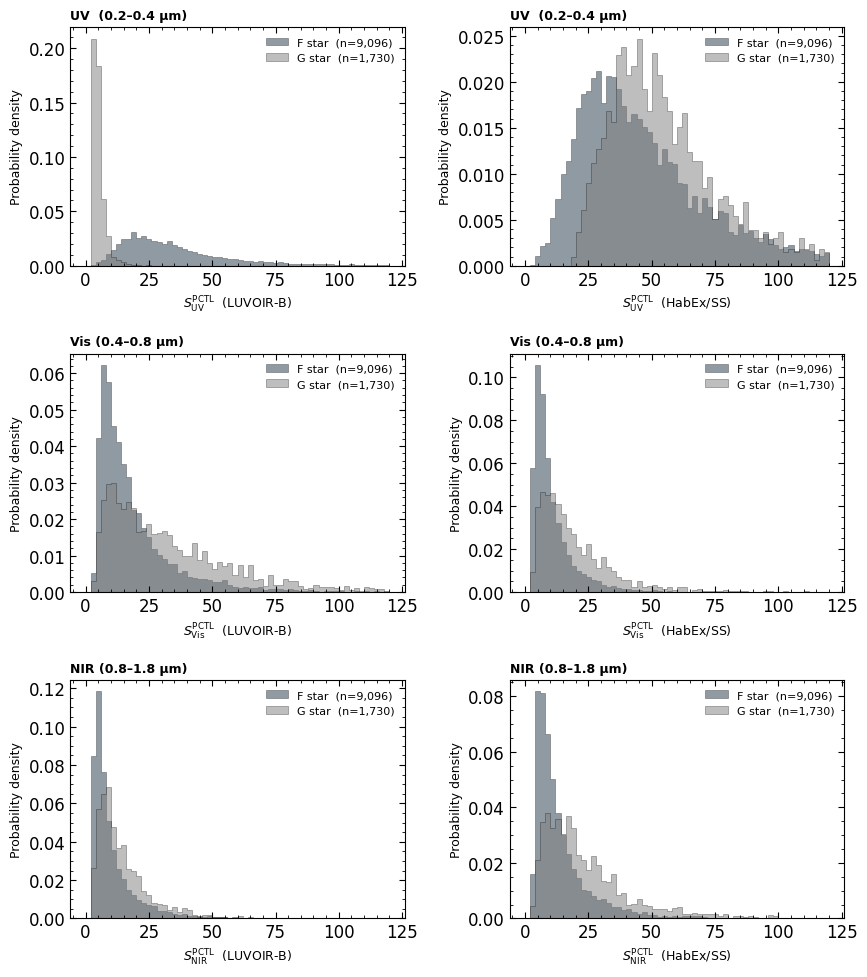

In [14]:
star_colors = {"F": "#223648", "G": "tab:gray"}
tel_labels = {"LUVOIR": "LUVOIR-B", "HABEX": "HabEx/SS"}
band_labels = {
    "UV": "UV  (0.2–0.4 µm)",
    "Vis": "Vis (0.4–0.8 µm)",
    "NIR": "NIR (0.8–1.8 µm)",
}
hist_range = (0, 120)

fig, axes = plt.subplots(3, 2, figsize=(9, 10))

for row, band in enumerate(BANDS):
    for col, tel in enumerate(TELESCOPES):
        ax = axes[row, col]
        col_key = SNR_COLS[tel][band]

        for st in ["F", "G"]:
            mask = meta_df["star_type"] == st
            vals = meta_df.loc[mask, col_key].dropna()
            ax.hist(
                vals,
                bins=60,
                range=hist_range,
                density=True,
                color=star_colors[st],
                alpha=0.5,
                label=f"{st} star  (n={len(vals):,})",
                histtype="stepfilled",
                edgecolor="k",
                linewidth=0.4,
            )

        ax.set_xlabel(
            f"$S_{{\\rm {band}}}^{{\\rm PCTL}}$  ({tel_labels[tel]})",
            fontsize=9,
        )
        ax.set_ylabel("Probability density", fontsize=9)
        ax.set_title(band_labels[band], loc="left", fontsize=9, fontweight="bold")
        ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
fig.savefig("../images/snr_pctl_distribution.pdf", bbox_inches="tight")
plt.show()

# Molecular Detection Thresholds

In [ ]:
CHEM_N_VALS = np.ones(N_PARAMS)
for mol, idx in CHEM_IDX.items():
    CHEM_N_VALS[idx] = norm_stats["outputs"][mol]["best_n"]

print("Normalisation exponents n_j (physical-space denominator scaling):")
for mol, idx in CHEM_IDX.items():
    print(
        f"  {mol:4s}  n = {CHEM_N_VALS[idx]:.2f}  →  σ_phys = {CHEM_N_VALS[idx]:.2f} × σ_total"
    )


def detection_fraction(tel, scale, era=None, threshold=DETECTION_SIGMA):
    """
    Detectable fraction using a physical mixing-ratio space criterion.
    """
    s_data = std_data[tel][scale]
    s_model = sigma_model[tel]
    s_total = np.sqrt(s_model**2 + s_data**2)

    # Physical-space effective uncertainty: σ_phys_j = n_j * σ_total_j
    sigma_phys = s_total * CHEM_N_VALS[np.newaxis, :]  # (N, 10)

    z_pred = get_mean_matrix(bootstrap[tel][scale])  # ẑ  (N, 10)
    sig = np.where(sigma_phys > 0, z_pred / sigma_phys, 0.0)

    if era is None:
        present = z_true > 0
        detected = sig > threshold
        with np.errstate(invalid="ignore"):
            return np.where(
                present.sum(axis=0) > 0,
                (detected & present).sum(axis=0) / present.sum(axis=0),
                np.nan,
            )

    mask = meta_df["era"].values == era
    present = z_true[mask] > 0
    detected = sig[mask] > threshold
    with np.errstate(invalid="ignore"):
        frac = np.where(
            present.sum(axis=0) > 0,
            (detected & present).sum(axis=0) / present.sum(axis=0),
            np.nan,
        )
    return frac


det_frac = {
    tel: {
        s: {era: detection_fraction(tel, s, era) for era in ERA_ORDER + [None]}
        for s in SNR_SCALES
    }
    for tel in ["LUVOIR", "HABEX"]
}
print("\nDetection fractions computed (physical-space criterion).")

Normalisation exponents n_j (physical-space denominator scaling):
  O2    n = 2.35  →  σ_phys = 2.35 × σ_total
  O3    n = 13.75  →  σ_phys = 13.75 × σ_total
  CH4   n = 6.75  →  σ_phys = 6.75 × σ_total
  CO2   n = 3.70  →  σ_phys = 3.70 × σ_total
  H2O   n = 5.60  →  σ_phys = 5.60 × σ_total
  N2    n = 0.40  →  σ_phys = 0.40 × σ_total

Detection fractions computed (physical-space criterion).


/tmp/ipykernel_3420281/2260632724.py:38: RuntimeWarning: invalid value encountered in divide
  sig = np.where(sigma_phys > 0, z_pred / sigma_phys, 0.0)


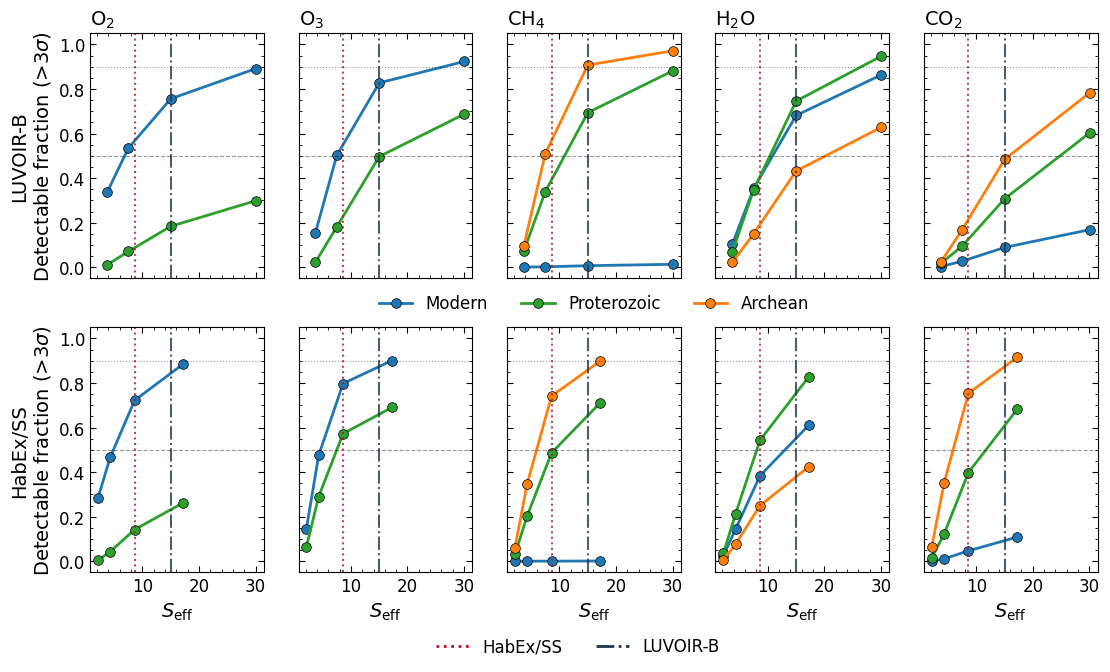

In [16]:
BIOSIGS = ["O2", "O3", "CH4", "H2O", "CO2"]

mission_ls = {"HabEx": ":", "LUVOIR": "-."}

fig, axes = plt.subplots(2, len(BIOSIGS), figsize=(13, 7), sharex=True, sharey=True)

for row, tel in enumerate(["LUVOIR", "HABEX"]):
    snr_x = snr_eff[tel]["Vis"]

    for col, mol in enumerate(BIOSIGS):
        j = CHEM_IDX[mol]
        ax = axes[row, col]

        for era in ERA_ORDER:
            fracs = [det_frac[tel][s][era][j] for s in SNR_SCALES]
            ax.plot(
                snr_x,
                fracs,
                "o-",
                color=ERA_COLORS[era],
                lw=2,
                ms=7,
                markeredgecolor="k",
                markeredgewidth=0.5,
                label=era.capitalize(),
            )

        # Mission reference lines — HabEx and LUVOIR only (no HWO)
        ax.axvline(
            mission_snr_vis["HabEx"],
            color=TEL_COLORS["HABEX"],
            lw=1.5,
            ls=mission_ls["HabEx"],
            alpha=0.8,
        )
        ax.axvline(
            mission_snr_vis["LUVOIR"],
            color=TEL_COLORS["LUVOIR"],
            lw=1.5,
            ls=mission_ls["LUVOIR"],
            alpha=0.8,
        )

        ax.axhline(0.5, color="k", lw=0.8, ls="--", alpha=0.4)
        ax.axhline(0.9, color="k", lw=0.8, ls=":", alpha=0.4)

        if row == 0:
            ax.set_title(CHEM_LABEL[mol], loc="left")
        if col == 0:
            tel_lbl = {"LUVOIR": "LUVOIR-B", "HABEX": "HabEx/SS"}[tel]
            ax.set_ylabel(f"{tel_lbl}\nDetectable fraction (>3$\\sigma$)")
        if row == 1:
            ax.set_xlabel("$S_{\\rm eff}$")
        if row == 0 and col == 2:
            ax.legend(loc="lower center", ncols=3, bbox_to_anchor=(0.5, -0.2))
        ax.set_ylim(-0.05, 1.05)

# Figure-level legend for mission lines
leg_patches = [
    Line2D([0], [0], color=TEL_COLORS["HABEX"], lw=2, ls=":", label="HabEx/SS"),
    Line2D([0], [0], color=TEL_COLORS["LUVOIR"], lw=2, ls="-.", label="LUVOIR-B"),
]
fig.legend(
    handles=leg_patches, loc="lower center", ncols=2, bbox_to_anchor=(0.5, -0.03)
)

fig.savefig("../images/detection_fraction_vs_snr.pdf", bbox_inches="tight")
plt.show()